### MAIN Quest 03

# GPT-1 PyTorch 한국어 챗봇 (Kiwi 버전)
---

본 실습은 GPT-1("Improving Language Understanding by Generative Pre-Training", Radford et al., 2018) 논문을 기반으로 Decoder-only 자동회귀 언어모델을 처음부터 구현하고, 한국어 챗봇 데이터셋(11,823쌍)으로 학습하는 전체 파이프라인을 경험하는 것을 목표로 한다.
<br><br>


## Transformer 대비 변경사항

- **Encoder 제거**: GPT-1은 Decoder-only 구조이므로 Encoder 및 Encoder 패딩 마스크가 없다.
- **Cross-Attention 제거**: `Masked Self-Attention → FFN` 두 서브레이어만 사용한다.
- **위치 임베딩 변경**: sinusoidal encoding 대신 학습 가능한 `nn.Embedding(max_len, d_model)` 위치 임베딩을 사용한다.
- **활성화 함수 변경**: FFN은 ReLU가 아닌 GELU를 사용한다.
- **학습 목표 변경**: `<SOS> Q <SEP> A <EOS>` 단일 시퀀스의 다음 토큰을 예측하는 causal language modeling이다.
- **출력층**: token embedding과 LM head 가중치를 공유(weight tying)한다.

원 논문(12 layers, d_model=768)보다 작은 6 layers, d_model=256 설정으로 실습 환경의 메모리와 학습 시간을 고려한다.


## 진행 과정
1. 데이터 정제 (전처리 및 토큰화)
2. 모델 구성 (GPT-1)
3. 학습 진행
4. 챗봇 결과 확인 및 시각화

# 0. 프로젝트 환경설정
----
PyTorch와 matplotlib을 사용한다. 결과 재현을 위해 시드를 고정하고, 그래프의 한국어 라벨이 깨지지 않도록 시스템 한국어 폰트를 자동 선택한다.

In [17]:
# [환경설정] matplotlib 한국어 폰트 설치 (Colab 전용)
# - 학습 loss 그래프 등 시각화에서 한글 라벨이 □(두부 글자)로 깨지는 것을 방지한다.
# - fonts-nanum: 나눔 폰트 패키지 설치
# - matplotlib 폰트 캐시(/root/.cache/matplotlib)를 삭제해야 새 폰트가 인식된다.
# - 주의: 설치 후 런타임(세션)을 재시작해야 폰트가 적용된다.

!apt-get -qq -y install fonts-nanum
!rm -rf /root/.cache/matplotlib

In [1]:
# [환경설정] 한국어 형태소 분석기 Kiwi 설치
# - GPT-1 원 논문은 BPE(Byte Pair Encoding, 40,000 merges)를 사용하지만,
#   본 실습에서는 한국어 특성에 맞춰 Kiwi 형태소 분석 기반 토큰화로 대체한다.

!pip install kiwipiepy

In [2]:
# [환경설정] 사용자 경고(UserWarning) 무시 설정
# - 라이브러리 버전 차이 등으로 발생하는 불필요한 경고 메시지를 숨겨
#   학습 로그 출력을 깔끔하게 유지한다.

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

## 라이브러리 로드

In [18]:
# [라이브러리 로드]

# --- 수치 연산 / 데이터 처리 ---
import numpy as np                     # 배열 연산, 시드 고정
import pandas as pd                    # CSV 데이터 로드 및 전처리
from collections import Counter       # 토큰 빈도 집계 → 어휘 사전 구축에 사용

# --- 딥러닝 프레임워크 (PyTorch) ---
import torch
import torch.nn as nn                  # 신경망 모듈 (Embedding, Linear, LayerNorm 등)
import torch.nn.functional as F        # 함수형 API (softmax 등)
from torch.utils.data import DataLoader, Dataset  # 미니배치 학습용 데이터 파이프라인

# --- 한국어 토크나이저 ---
from kiwipiepy import Kiwi             # 한국어 형태소 분석기 (BPE 대체)

# --- 시각화 ---
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- 유틸리티 ---
import math                            # sqrt(d_k) 스케일링, cosine 스케줄, perplexity 계산
import re                              # 정규식 기반 문장 전처리
import os
import time
import random
from pathlib import Path               # 체크포인트 디렉터리 관리

import seaborn

# 버전 확인 (재현성 기록용)
print(torch.__version__)
print(np.__version__)
print("kiwipiepy tokenizer ready")
print(mpl.__version__)

2.11.0+cu128
2.0.2
kiwipiepy tokenizer ready
3.10.0


In [4]:
# [재현성/디바이스 설정]

# 결과 재현성 확보: PyTorch와 NumPy의 난수 시드를 고정하여
# 가중치 초기화, 데이터 셔플, 샘플링 결과를 동일하게 재현할 수 있게 한다.
torch.manual_seed(42)
np.random.seed(42)

# GPU 사용 설정: CUDA GPU가 있으면 GPU, 없으면 CPU를 사용한다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


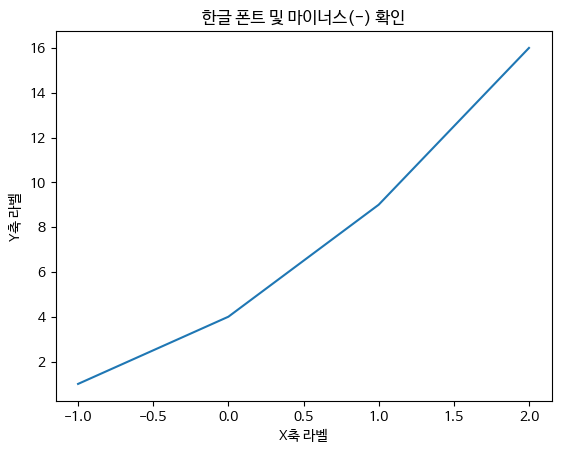

In [19]:
# [시각화 설정] matplotlib 한글 폰트 적용

# 앞서 설치한 나눔바른고딕 폰트를 기본 폰트로 지정
plt.rc('font', family='NanumBarunGothic')
# 한글 폰트 사용 시 마이너스(-) 기호가 깨지는 문제 방지
plt.rcParams['axes.unicode_minus'] = False

# 한글/마이너스 기호가 정상 출력되는지 확인하는 테스트 그래프
plt.plot([-1, 0, 1, 2], [1, 4, 9, 16])
plt.title('한글 폰트 및 마이너스(-) 확인')
plt.xlabel('X축 라벨')
plt.ylabel('Y축 라벨')
plt.show()

In [5]:
# [변경] GPT-1 축소 설정을 한 곳에 모으고, Encoder 관련 설정은 제거
# GPT-1 논문(Radford et al., 2018) 원 설정과의 비교:
#   - 논문: 12 layers, d_model=768, 12 heads, d_ff=3072, BPE vocab 40,000, max_len 512
#   - 실습: 6 layers, d_model=256,  8 heads, d_ff=1024, vocab 8,000,        max_len 40
#   → 실습 환경(Colab)의 메모리와 학습 시간을 고려한 축소판이다.

MAX_LEN = 40            # 시퀀스 최대 길이 (논문: 512 토큰)
D_MODEL = 256           # 임베딩/은닉 상태 차원 (논문: 768)
N_LAYERS = 6            # Decoder 블록 수 (논문: 12)
N_HEADS = 8             # 어텐션 헤드 수 (논문: 12)
D_FF = 1024             # FFN 내부 차원, 보통 4*d_model (논문: 3072)
DROPOUT = 0.1           # 드롭아웃 비율 (논문과 동일: residual/embedding/attention dropout 0.1)
BATCH_SIZE = 64         # 미니배치 크기 (논문: 64로 동일)
EPOCHS = 20             # 학습 epoch 수 (논문: 100 epochs)
LR = 2.5e-4             # 최대 학습률 (논문과 동일: max lr 2.5e-4)
TOKENIZER_VOCAB_SIZE = 8000  # 어휘 사전 최대 크기 (논문: BPE 40,000 merges)

# 멀티헤드 어텐션에서 d_model을 헤드 수로 균등 분할해야 하므로 나누어떨어짐을 보장
assert D_MODEL % N_HEADS == 0

# 1. 텍스트 데이터 준비

---
챗봇에 사용할 텍스트 데이터를 다운로드하여 전처리, 토큰화 등 정제 작업을 수행한다.

## 데이터 다운로드

---
songys/Chatbot_data에서 `ChatbotData.csv` 데이터를 저장하여 사용한다.<br>
`csv` 파일이므로 `pandas` 라이브러리를 사용한다.<br>
데이터는 한 줄에 `Q,A,label`로 구성되어 있다. 데이터의 질문과 답변을 각각 `questions`, `answers` 변수에 나눠서 저장한다.

In [6]:
# [환경설정] Colab 데이터 디렉터리 준비

# data 폴더 생성 (이미 존재하면 만들지 않음)
!mkdir -p /content/data

CURRENT_DIR = os.getcwd()                          # 현재 작업 디렉터리 (/content)
DATA_DIR = os.path.join(CURRENT_DIR, 'data')       # 데이터 저장 경로 (/content/data)

os.makedirs(DATA_DIR, exist_ok=True)               # 파이썬 레벨에서도 생성 보장
print(CURRENT_DIR)
print(DATA_DIR)

/content
/content/data


In [7]:
# [데이터 로드] songys/Chatbot_data 한국어 챗봇 데이터셋

# GitHub raw URL에서 CSV를 직접 로드한다.
# - usecols: Q(질문), A(답변), label(감정 라벨) 세 컬럼만 사용
# - dropna : 질문/답변이 비어있는 행 제거
DATA_URL = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
df = pd.read_csv(DATA_URL, usecols=["Q", "A", "label"]).dropna(subset=["Q", "A"]).copy()

# 재실행 시 네트워크 없이도 쓸 수 있도록 백업 저장
df.to_csv(f"{DATA_DIR}/ChatbotData.csv", index=False, encoding="utf-8-sig")

# 질문과 답변을 각각 분리하여 저장
questions = df["Q"]
answers = df["A"]

# 데이터 개수 및 샘플 확인
print(len(questions))
print(len(answers))
print("\nSample Data Check: ")
print("Question: ", questions[0])
print("Answer: ", answers[0])

11823
11823

Sample Data Check: 
Question:  12시 땡!
Answer:  하루가 또 가네요.


# 2. 데이터 정제
---


## 데이터 전처리
---
데이터를 정제할 수 있는 `preprocess_sentence()` 함수 구현한다.

- 영문자의 경우 모두 소문자로 변환
- 영문자와 한글, 숫자, 그리고 주요 특수문자를 제외하고 정규식을 활용하여 모두 제거

In [8]:
# [데이터 정제] 전처리 함수 정의

def preprocess_sentence(sentence):
  # 1) 영문자: 대문자를 모두 소문자로 변환 (어휘 사전 크기 축소 효과)
  sentence = sentence.lower()
  # 2) 한글(가-힣), 영문 소문자, 숫자, 주요 특수문자(?.!,¿)를 제외한
  #    나머지 문자를 정규식으로 모두 공백 치환
  sentence = re.sub(r"[^a-z0-9가-힣?.!,¿]+", " ", sentence)
  # 3) 연속된 공백을 하나로 축소하고 양끝 공백 제거
  sentence = re.sub(r"\s+", " ", str(sentence)).strip()
  # 4) 구두점(?!,.) 앞뒤에 공백을 삽입해 구두점을 독립 토큰으로 분리
  return re.sub(r"\s*([?!,.])\s*", r" \1 ", sentence).strip()

print("전처리 함수 정의")

전처리 함수 정의


## 토큰 임베딩
---
토큰화는 Kiwi 라이브러리를 사용하여 진행한다

토큰화 함수(`build_corpus()`)는 다음의 조건을 만족한다.

+ 소스 문장 데이터(questions)와 타겟 문장 데이터(answers)를 입력 받음
+ 앞서 정의한 preprocess_sentence() 함수로 데이터 전처리
+ 토큰화는 전달받은 토크나이즈 함수를 사용한다. (Kiwi() 사용)
+ 토큰의 개수가 일정 길이 이상인 문장은 데이터에서 제외한다. (MAX_LEN = 40)
+ 중복되는 문장은 데이터에서 제외한다. 소스 : 타겟 쌍을 비교하지 않고 소스는 소스대로 타겟은 타겟대로 검사한다. 중복 쌍이 흐트러지지 않도록 유의해서 수행한다.
+ 구현한 함수를 활용하여 `questions` 와 `answers` 를 각각 `que_corpus` , `ans_corpus` 에 토큰화하여 저장한다.

In [9]:
# [변경] BPE 대신 Kiwi 형태소 토큰화와 빈도 기반 어휘 사전을 사용
# - GPT-1 논문은 40,000 merges의 BPE를 사용하지만,
#   한국어 실습이므로 Kiwi 형태소 분석 결과(token.form)를 토큰 단위로 사용한다.

tokenizer = Kiwi()

# 특수 토큰 정의 (앞쪽 인덱스에 고정 배치)
# - <PAD>: 배치 내 길이 맞춤용 패딩          (id=0)
# - <UNK>: 어휘 사전에 없는 토큰(OOV) 대체    (id=1)
# - <SOS>: 시퀀스 시작(Start of Sequence)     (id=2)
# - <SEP>: 질문(Q)과 답변(A)의 경계 구분자     (id=3)
# - <EOS>: 시퀀스 종료(End of Sequence)       (id=4)
SPECIAL_TOKENS = ["<PAD>", "<UNK>", "<SOS>", "<SEP>", "<EOS>"]

def kiwi_tokenize(sentence):
    # 전처리 → Kiwi 형태소 분석 → 각 형태소의 표면형(form)만 추출
    return [token.form for token in tokenizer.tokenize(preprocess_sentence(sentence))]

def build_filtered_corpora(questions, answers, tokenize_fn):
    """조건에 맞는 Q/A 쌍만 걸러 토큰화된 말뭉치를 만든다.
    - 전처리 후 토큰화
    - 토큰 수가 MAX_LEN 이상인 문장이 포함된 쌍 제외
    - 질문/답변 각각 독립적으로 중복 검사하되, 쌍 단위로 함께 제외하여
      (질문 i ↔ 답변 i) 대응 관계가 흐트러지지 않게 유지
    """
    que_corpus, ans_corpus = [], []
    seen_questions, seen_answers = set(), set()
    for question, answer in zip(questions, answers):
        question = preprocess_sentence(question)
        answer = preprocess_sentence(answer)
        question_tokens, answer_tokens = tokenize_fn(question), tokenize_fn(answer)
        # 질문 또는 답변이 이미 등장하거나 MAX_LEN 이상이면 현재 쌍 전체를 제외한다.
        if (question in seen_questions or answer in seen_answers or
                len(question_tokens) >= MAX_LEN or len(answer_tokens) >= MAX_LEN):
            continue
        seen_questions.add(question)
        seen_answers.add(answer)
        que_corpus.append(question_tokens)
        ans_corpus.append(answer_tokens)
    return que_corpus, ans_corpus

que_corpus, ans_corpus = build_filtered_corpora(questions, answers, kiwi_tokenize)
print(f"전처리 완료: {len(df):,}개 → {len(que_corpus):,}개 쌍 (MAX_LEN={MAX_LEN})")

# --- 빈도 기반 어휘 사전 구축 ---
# 전체 말뭉치(질문+답변)의 토큰 빈도를 집계한 뒤,
# 특수 토큰 자리를 제외한 상위 (VOCAB_SIZE - 5)개 토큰만 어휘 사전에 등록한다.
counts = Counter()
for tokens in que_corpus + ans_corpus:
    counts.update(tokens)
vocab_tokens = [token for token, _ in counts.most_common(TOKENIZER_VOCAB_SIZE - len(SPECIAL_TOKENS))]

# id ↔ token 양방향 매핑 테이블 (특수 토큰이 0~4번 인덱스를 차지)
id_to_token = SPECIAL_TOKENS + vocab_tokens
token_to_id = {token: idx for idx, token in enumerate(id_to_token)}
PAD_ID, UNK_ID, SOS_ID, SEP_ID, EOS_ID = (token_to_id[token] for token in SPECIAL_TOKENS)
VOCAB_SIZE = len(id_to_token)
print(f"rows={len(df):,}, vocab={VOCAB_SIZE}, PAD={PAD_ID}, SOS={SOS_ID}, SEP={SEP_ID}, EOS={EOS_ID}")

전처리 완료: 11,823개 → 7,733개 쌍 (MAX_LEN=40)
rows=11,823, vocab=4614, PAD=0, SOS=2, SEP=3, EOS=4


## 데이터셋 구성

In [10]:
# [변경] seq2seq 입력/출력 분리가 아닌 Q+A 단일 시퀀스의 causal LM shift 타겟
# - Transformer 챗봇: (Encoder 입력=Q, Decoder 입력=A) 두 시퀀스로 분리
# - GPT-1 챗봇      : "<SOS> Q <SEP> A <EOS>" 하나의 시퀀스로 결합하고,
#                     한 칸 밀린(shift) 다음 토큰을 예측하는 언어모델 학습을 수행

def encode(text):
    # 문장 → 토큰 → 정수 id 리스트. 사전에 없는 토큰은 UNK_ID로 대체
    return [token_to_id.get(token, UNK_ID) for token in kiwi_tokenize(text)]

def decode(token_ids):
    # 정수 id 리스트 → 문자열. 특수 토큰(PAD/SOS/SEP/EOS)은 출력에서 제외
    tokens = [id_to_token[token_id] for token_id in token_ids if token_id < VOCAB_SIZE and token_id not in {PAD_ID, SOS_ID, SEP_ID, EOS_ID}]
    return " ".join(tokens)

def build_sequence(question, answer):
    # 학습용 단일 시퀀스 구성: <SOS> + Q토큰 + <SEP> + A토큰 + <EOS>
    ids = [SOS_ID] + encode(question) + [SEP_ID] + encode(answer) + [EOS_ID]
    # MAX_LEN 초과 시 잘라내되 마지막은 반드시 <EOS>로 끝나도록 보정
    ids = ids[:MAX_LEN - 1] + [EOS_ID] if len(ids) > MAX_LEN else ids
    # 남는 길이는 <PAD>로 채워 모든 시퀀스를 MAX_LEN으로 통일
    return ids + [PAD_ID] * (MAX_LEN - len(ids))

sequences = [build_sequence(q, a) for q, a in zip(df["Q"], df["A"])]

class ChatbotLMDataset(Dataset):
    # 이번 과제는 pretrain만 고려하며 fine-tuning 포맷은 만들지 않는다.
    def __init__(self, token_sequences):
        self.token_sequences = token_sequences

    def __len__(self):
        return len(self.token_sequences)

    def __getitem__(self, index):
        ids = torch.tensor(self.token_sequences[index], dtype=torch.long)
        # causal LM의 핵심: 입력은 [:-1], 타겟은 [1:] (한 칸 shift)
        #   입력:  <SOS> t1 t2 ... t_{n-1}
        #   타겟:  t1   t2 t3 ...  t_n     → 각 위치에서 "다음 토큰"을 맞추게 학습
        return ids[:-1], ids[1:]

dataset = ChatbotLMDataset(sequences)
# shuffle=True: epoch마다 순서 섞기 / drop_last=True: 마지막 자투리 배치 제거
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# 배치 shape 및 디코딩 결과 확인 (MAX_LEN=40에서 shift로 1이 줄어 39가 된다)
input_ids, target_ids = next(iter(dataloader))
print("input_ids shape :", input_ids.shape)
print("target_ids shape:", target_ids.shape)
print("first input decoded:", decode(input_ids[0].tolist()))

input_ids shape : torch.Size([64, 39])
target_ids shape: torch.Size([64, 39])
first input decoded: 와인 한 잔 하 ᆯ까 저 ᆫ 술 을 마시 지 못 하 어요 .


# 3. 모델 설계

## 모델 구현과 GPT-1 논문의 대응 관계

이후 코드는 **GPT-1 논문 "Improving Language Understanding by Generative Pre-Training" (Radford, Narasimhan, Salimans, Sutskever, 2018)** 의 Section 3.1(Unsupervised pre-training)과 Section 4.1(Model specifications)을 근거로 구현한다. 본 실습은 논문의 두 단계(사전학습 + 지도 미세조정) 중 **비지도 사전학습(Eq. 1, 2)** 부분만 다룬다.

핵심 수식 요약:

| 논문 수식 | 의미 | 구현 위치 |
|---|---|---|
| $L_1(\mathcal{U}) = \sum_i \log P(u_i \mid u_{i-k}, \ldots, u_{i-1}; \Theta)$ (Eq. 1) | causal LM 목적함수 | 학습 루프 (`CrossEntropyLoss`) |
| $h_0 = U W_e + W_p$ (Eq. 2) | 토큰 + 위치 임베딩 | `GPTInputEmbedding` |
| $h_l = \texttt{transformer\_block}(h_{l-1})$ (Eq. 2) | Decoder 블록 반복 | `GPTDecoderBlock` × 6 |
| $P(u) = \mathrm{softmax}(h_n W_e^\top)$ (Eq. 2) | 출력 분포 (weight tying) | `lm_head` + 가중치 공유 |

### 3.1 입력 임베딩 — 논문 Section 3.1, Eq. 2의 첫 줄

$$h_0 = U W_e + W_p$$

- $U = (u_{-k}, \ldots, u_{-1})$ : 입력 토큰(정수 id) 시퀀스
- $W_e$ : 토큰 임베딩 행렬 → `self.token_emb` = `nn.Embedding(vocab_size, d_model)`
- $W_p$ : **학습되는** 위치 임베딩 행렬 → `self.pos_emb` = `nn.Embedding(max_len, d_model)`

**원 Transformer와의 차이 (논문 Section 4.1)**: 원 Transformer는 고정된 sinusoidal positional encoding

$$PE_{(pos, 2i)} = \sin(pos/10000^{2i/d_{model}}), \quad PE_{(pos, 2i+1)} = \cos(pos/10000^{2i/d_{model}})$$

을 사용하지만, GPT-1 논문은 "we used **learned position embeddings** instead of the sinusoidal version proposed in the original work" 라고 명시한다. 즉 위치 벡터도 역전파로 학습되는 파라미터다.

구현 세부:
- `padding_idx=pad_id` : `<PAD>` 토큰의 임베딩을 0 벡터로 고정하고 gradient 갱신을 막는다.
- `torch.arange(T)` 로 위치 인덱스 $[0, 1, \ldots, T{-}1]$ 를 만들어 브로드캐스팅으로 배치 전체에 더한다.
- 마지막 Dropout은 논문의 embedding dropout (rate 0.1)에 해당한다.

In [11]:
# [변경] Sinusoidal PE 제거 → learned position embedding (GPT-1 논문)
# 논문 근거 (Section 3.1, Eq. 2):  h_0 = U·W_e + W_p
#   - W_e: 토큰 임베딩 행렬 → self.token_emb
#   - W_p: "학습되는" 위치 임베딩 행렬 → self.pos_emb
#   - 논문 원문: "we used learned position embeddings instead of the
#     sinusoidal version proposed in the original work"

class GPTInputEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_len, pad_id, dropout):
        super().__init__()
        # W_e: (vocab_size × d_model) 토큰 임베딩. padding_idx로 <PAD> 벡터는 0으로 고정
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        # W_p: (max_len × d_model) 위치 임베딩. sin/cos 고정값이 아니라 학습 파라미터
        self.pos_emb = nn.Embedding(max_len, d_model)
        # 논문의 embedding dropout (rate=0.1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, T) 정수 토큰 id → positions: (1, T) = [0, 1, ..., T-1]
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        # h_0 = U·W_e + W_p  (브로드캐스팅으로 배치 전체에 동일 위치 임베딩 더함)
        return self.dropout(self.token_emb(x) + self.pos_emb(positions))

# 단위 테스트: (2, 39) 입력 → (2, 39, 256) 출력이면 정상
embedding_check = GPTInputEmbedding(VOCAB_SIZE, D_MODEL, MAX_LEN, PAD_ID, DROPOUT).to(device)
print("embedding output shape:", embedding_check(input_ids[:2].to(device)).shape)

embedding output shape: torch.Size([2, 39, 256])


### 3.2 Masked Multi-Head Self-Attention과 Position-wise FFN — 논문 Section 3.1 & 4.1

GPT-1은 Transformer(Vaswani et al., 2017)의 **Decoder 블록에서 Cross-Attention을 제거한** 구조를 그대로 사용한다. 논문 표현으로는 "multi-layer Transformer decoder"이며, 각 토큰은 **자신의 왼쪽(과거) 토큰에만** attend 할 수 있다.

**1) Causal(하삼각) 마스크** — 단방향 언어모델의 핵심

$$\text{mask}_{ij} = \begin{cases} \text{True} & j \le i \;(\text{과거 허용}) \\ \text{False} & j > i \;(\text{미래 차단}) \end{cases}$$

`torch.tril`로 하삼각 행렬을 만들고, False 위치의 score를 $-\infty$로 채우면 softmax 후 확률이 0이 된다. 여기에 `<PAD>` 위치를 차단하는 pad mask를 AND 결합한다.

**2) Scaled Dot-Product Attention** (Transformer 논문 수식, GPT-1이 차용)

$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

$\sqrt{d_k}$ 로 나누는 이유: 차원이 커질수록 내적값의 분산이 커져 softmax가 포화(gradient 소실)되는 것을 방지한다. 본 실습에서 $d_k = d_{model}/h = 256/8 = 32$.

**3) Multi-Head 결합**

$$\mathrm{MultiHead}(x) = \mathrm{Concat}(\mathrm{head}_1, \ldots, \mathrm{head}_h)\,W^O, \qquad \mathrm{head}_i = \mathrm{Attention}(xW_i^Q,\, xW_i^K,\, xW_i^V)$$

코드에서는 $W^Q, W^K, W^V$를 헤드별로 나누지 않고 `d_model → d_model` 선형층 하나로 계산한 뒤 `view + transpose`로 헤드 차원을 분리한다 (수학적으로 동일, 연산 효율적).

**4) Position-wise FFN — ReLU 대신 GELU (GPT-1의 변경점)**

$$\mathrm{FFN}(x) = \mathrm{GELU}(xW_1 + b_1)\,W_2 + b_2$$

원 Transformer는 $\max(0, \cdot)$ (ReLU)를 쓰지만, GPT-1 논문은 "For the activation function, we used the Gaussian Error Linear Unit (GELU)" 라고 명시한다. 차원은 $256 \to 1024 \to 256$ (논문은 $768 \to 3072 \to 768$).

**5) Decoder 블록 구성 — 서브레이어 3개 → 2개**

| 원 Transformer Decoder | GPT-1 Decoder-only |
|---|---|
| Masked Self-Attn → **Cross-Attn** → FFN | Masked Self-Attn → FFN |

Encoder가 없으므로 Encoder 출력을 참조하는 Cross-Attention이 불필요하다. 각 서브레이어는 원 Transformer와 동일하게 residual connection + LayerNorm(Post-LN)으로 감싼다:

$$x \leftarrow \mathrm{LayerNorm}\big(x + \mathrm{Dropout}(\mathrm{Sublayer}(x))\big)$$

In [12]:
# [변경] Encoder용 패딩 마스크 제거, causal + pad 결합 마스크만 사용

def make_causal_mask(T, device):
    # 하삼각 행렬(torch.tril): 위치 i는 j<=i 인 과거 토큰만 볼 수 있다 (미래 차단).
    # 논문 표현: "masked self-attention where every token can only attend
    # to context to its left"  → GPT-1의 핵심인 단방향(left-to-right) 제약
    # shape: (1, 1, T, T) — (batch, head) 차원에 브로드캐스팅
    return torch.tril(torch.ones(T, T, dtype=torch.bool, device=device)).unsqueeze(0).unsqueeze(0)

def make_pad_mask(x, pad_id):
    # <PAD> 위치는 어텐션 계산에서 제외 (True=유효 토큰, False=패딩)
    # shape: (B, 1, 1, T) — 각 key 위치의 유효 여부
    return (x != pad_id).unsqueeze(1).unsqueeze(2)

class MultiHeadSelfAttention(nn.Module):
    # [변경] Cross-Attention 없음. Self-Attention만 존재 (Decoder-only)
    # 수식 (Vaswani et al., 2017 — GPT-1이 그대로 차용):
    #   Attention(Q, K, V) = softmax(Q·K^T / sqrt(d_k)) · V
    #   MultiHead(x) = Concat(head_1, ..., head_h) · W^O
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads       # d_k = d_model / h (256/8 = 32)
        # W^Q, W^K, W^V: 입력을 Query/Key/Value로 사영하는 선형층
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        # W^O: 헤드들을 이어붙인 뒤 다시 d_model로 사영
        self.out_proj = nn.Linear(d_model, d_model)
        # attention dropout (논문 rate=0.1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        B, T, D = x.shape
        def split_heads(layer):
            # (B, T, D) → (B, n_heads, T, head_dim): 헤드별 병렬 어텐션을 위해 분할
            return layer.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        q, k, v = map(split_heads, (self.q_proj(x), self.k_proj(x), self.v_proj(x)))
        # 스케일드 닷 프로덕트: Q·K^T / sqrt(d_k) — 내적값 분산 폭주로 인한
        # softmax 포화(gradient 소실)를 막기 위해 sqrt(d_k)로 나눈다.
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        # 마스크가 False인 위치(미래 토큰, 패딩)는 -inf → softmax 후 확률 0
        scores = scores.masked_fill(~mask, float("-inf"))
        attention = self.dropout(F.softmax(scores, dim=-1))
        # 가중합 후 헤드 결합: (B, h, T, d_k) → (B, T, D)
        out = (attention @ v).transpose(1, 2).contiguous().view(B, T, D)
        return self.out_proj(out)

class PositionwiseFFN(nn.Module):
    # [변경] ReLU → GELU (GPT-1 논문)
    # 수식: FFN(x) = GELU(x·W_1 + b_1)·W_2 + b_2
    #   - 원 Transformer: max(0, x·W_1 + b_1)·W_2 + b_2  (ReLU)
    #   - GPT-1 원문: "we use the Gaussian Error Linear Unit (GELU)"
    #   - 차원: d_model(256) → d_ff(1024) → d_model(256)
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model), nn.Dropout(dropout))

    def forward(self, x):
        return self.net(x)

class GPTDecoderBlock(nn.Module):
    # [변경] Cross-Attn 서브레이어 삭제 → 서브레이어 3개에서 2개로 축소
    # 원 Transformer Decoder: [Masked Self-Attn → Cross-Attn → FFN]
    # GPT-1 Decoder-only    : [Masked Self-Attn → FFN]  (Encoder가 없으므로)
    # 각 서브레이어는 residual connection + LayerNorm 으로 감싼다 (Post-LN):
    #   x = LayerNorm(x + Dropout(Sublayer(x)))
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ffn = PositionwiseFFN(d_model, d_ff, dropout)
        self.dropout = nn.Dropout(dropout)        # residual dropout (rate=0.1)
        self.norm1 = nn.LayerNorm(d_model)        # Self-Attn 뒤 LayerNorm
        self.norm2 = nn.LayerNorm(d_model)        # FFN 뒤 LayerNorm

    def forward(self, x, mask):
        # 서브레이어 1: Masked Self-Attention + residual + LayerNorm
        x = self.norm1(x + self.dropout(self.self_attn(x, mask)))
        # 서브레이어 2: Position-wise FFN + residual + LayerNorm
        return self.norm2(x + self.dropout(self.ffn(x)))

### 3.3 GPT-1 전체 모델 — 논문 Section 3.1, Eq. 2

논문의 순전파 수식 세 줄이 `GPT1.forward`에 그대로 대응된다.

$$h_0 = U W_e + W_p$$
$$h_l = \texttt{transformer\_block}(h_{l-1}) \quad \forall l \in [1, n]$$
$$P(u) = \mathrm{softmax}(h_n W_e^\top)$$

| 수식 | 코드 |
|---|---|
| $h_0 = U W_e + W_p$ | `h = self.embedding(x)` |
| $h_l = \texttt{transformer\_block}(h_{l-1})$ | `for block in self.blocks: h = block(h, mask)` (본 실습 $n=6$, 논문 $n=12$) |
| $P(u) = \mathrm{softmax}(h_n W_e^\top)$ | `self.lm_head(h)` + `lm_head.weight = token_emb.weight` |

**Weight tying**: 논문 수식에서 출력층 가중치가 별도 행렬이 아니라 토큰 임베딩의 전치 $W_e^\top$ 인 점에 주목한다. 코드에서 `lm_head.weight`를 `token_emb.weight`와 공유하여 이를 그대로 구현했다. 파라미터 수가 줄고(vocab 4,614 × 256 ≈ 118만 개 절약) 일반화에도 도움이 된다. softmax는 학습 시 `CrossEntropyLoss` 내부에서, 생성 시 `F.softmax`에서 적용되므로 `forward`는 logits만 반환한다.

**가중치 초기화**: 논문 원문의 "a simple weight initialization of $N(0, 0.02)$" 를 따라 모든 Linear/Embedding 가중치를 평균 0, 표준편차 0.02의 정규분포로 초기화한다.

**마스크 결합**: `causal mask & pad mask` — 미래 토큰과 패딩 토큰을 동시에 차단한 마스크를 모든 블록에 공통으로 전달한다.

In [13]:
# [변경] Encoder와 encoder-decoder 연결 없이 causal decoder blocks만 쌓은 GPT-1
# 논문 근거 (Section 3.1, Eq. 2):
#   h_0 = U·W_e + W_p                          → self.embedding
#   h_l = transformer_block(h_{l-1}), l=1..n   → self.blocks 반복 (n=6)
#   P(u) = softmax(h_n · W_e^T)                → self.lm_head (W_e 전치 = weight tying)

class GPT1(nn.Module):
    def __init__(self, vocab_size, max_len, d_model, n_layers, n_heads, d_ff, dropout, pad_id):
        super().__init__()
        self.pad_id = pad_id
        # h_0: 토큰 임베딩 + 학습형 위치 임베딩
        self.embedding = GPTInputEmbedding(vocab_size, d_model, max_len, pad_id, dropout)
        # h_1 ~ h_n: 동일 구조의 decoder block을 n_layers개 쌓음
        self.blocks = nn.ModuleList([GPTDecoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        # LM head: 은닉 상태 → 어휘 분포 logits (bias 없음)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        # weight tying: P(u) = softmax(h_n·W_e^T) 수식 그대로,
        # LM head 가중치를 토큰 임베딩 W_e와 공유 → 파라미터 절약 + 성능 향상
        self.lm_head.weight = self.embedding.token_emb.weight  # weight tying

    def forward(self, x):
        T = x.size(1)
        # causal 마스크(미래 차단)와 pad 마스크(패딩 차단)를 AND로 결합
        mask = make_causal_mask(T, x.device) & make_pad_mask(x, self.pad_id)
        h = self.embedding(x)                 # h_0
        for block in self.blocks:
            h = block(h, mask)                # h_l = transformer_block(h_{l-1})
        return self.lm_head(h)                # 각 위치의 다음 토큰 logits (B, T, V)

def init_weights(module):
    # GPT-1 논문의 가중치 초기화: N(0, 0.02) 정규분포
    # 원문: "weight initialization of N(0, 0.02) was sufficient"
    if isinstance(module, (nn.Linear, nn.Embedding)):
        nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.zeros_(module.bias)

model = GPT1(VOCAB_SIZE, MAX_LEN, D_MODEL, N_LAYERS, N_HEADS, D_FF, DROPOUT, PAD_ID).to(device)
model.apply(init_weights)
print(model)
print(f"trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

GPT1(
  (embedding): GPTInputEmbedding(
    (token_emb): Embedding(4614, 256, padding_idx=0)
    (pos_emb): Embedding(40, 256)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (blocks): ModuleList(
    (0-5): 6 x GPTDecoderBlock(
      (self_attn): MultiHeadSelfAttention(
        (q_proj): Linear(in_features=256, out_features=256, bias=True)
        (k_proj): Linear(in_features=256, out_features=256, bias=True)
        (v_proj): Linear(in_features=256, out_features=256, bias=True)
        (out_proj): Linear(in_features=256, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): PositionwiseFFN(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1024, out_features=256, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (norm1): LayerNorm((256,), eps=

## Train Loop

### 3.4 학습 목적함수와 최적화 — 논문 Section 3.1 & 4.1

**비지도 사전학습 목적함수 (논문 Eq. 1)** — 토큰 시퀀스 $\mathcal{U} = \{u_1, \ldots, u_n\}$ 에 대해 다음 로그 가능도를 최대화한다.

$$L_1(\mathcal{U}) = \sum_i \log P(u_i \mid u_{i-k}, \ldots, u_{i-1}; \Theta)$$

코드의 `nn.CrossEntropyLoss`는 $-\log P(\text{다음 토큰})$의 평균을 최소화하므로 $L_1$ 최대화와 수학적으로 동일하다. `ignore_index=PAD_ID`로 패딩 위치는 손실에서 제외한다.

**논문의 학습 설정과의 대응 (Section 4.1 "Model specifications")**

| 논문 설정 | 본 코드 |
|---|---|
| Adam optimizer, max lr $2.5 \times 10^{-4}$ | `torch.optim.Adam(lr=2.5e-4)` — 동일 |
| 처음 2000 스텝 동안 lr 선형 증가(warmup) | `warmup_steps = min(2000, total_steps//10)` — 소규모 데이터에 맞게 상한 조정 |
| 이후 cosine schedule로 0까지 감소 | `0.5 * (1 + cos(π·progress))` — 동일 |
| 100 epochs, batch 64 | 20 epochs, batch 64 — epoch만 축소 |

체크포인트 저장, best model 추적, early stopping은 논문에 없는 실습 편의 기능이다. `ppl = exp(loss)`는 언어모델의 표준 평가 지표인 perplexity로, "모델이 매 위치에서 평균 몇 개의 토큰 사이에서 고민하는가"로 해석할 수 있다.

In [14]:
# [변경] autoregressive LM 학습에 체크포인트, best model, early stopping을 추가
# [추가] tqdm 진행률 바 + history(epoch별 loss 기록) — 이후 학습 곡선 시각화에 활용
from tqdm.notebook import tqdm   # Jupyter/Colab용 위젯 기반 진행률 바

# 손실 함수: <PAD> 위치는 loss 계산에서 제외 (ignore_index)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
# 옵티마이저: Adam, 최대 학습률 2.5e-4 (GPT-1 논문과 동일 설정)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# 학습률 스케줄: 논문의 "linear warmup 2000 steps → cosine annealing to 0"
total_steps = EPOCHS * len(dataloader)
warmup_steps = min(2000, max(1, total_steps // 10))   # 소규모 데이터라 warmup 상한 조정
def lr_lambda(step):
    if step < warmup_steps: return (step + 1) / warmup_steps          # 선형 warmup
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))                   # cosine decay
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# --- 체크포인트 / early stopping 설정 ---
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)
CHECKPOINT_EVERY = 5          # 5 epoch마다 정기 체크포인트 저장
PATIENCE = 3                  # loss 개선 없는 epoch가 3회 누적되면 조기 종료
best_loss = float("inf")
epochs_without_improvement = 0

# [추가] epoch별 평균 loss 기록 저장소 → 학습 종료 후 loss 곡선 plot에 사용
history = {"train_loss": []}

def save_checkpoint(path, epoch, loss):
    # 학습 재개에 필요한 모든 상태(모델/옵티마이저/스케줄러)를 저장
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "loss": loss,
        "vocab_size": VOCAB_SIZE,
    }, path)

for epoch in range(1, EPOCHS + 1):
    model.train()                             # 학습 모드 (dropout 활성화)
    running_loss = 0.0

    # [추가] dataloader를 tqdm으로 감싸 배치 단위 진행률을 표시
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False)

    for batch_input, batch_target in progress_bar:   # ← dataloader가 아닌 progress_bar 순회
        batch_input, batch_target = batch_input.to(device), batch_target.to(device)
        # 순전파: (B, T) → (B, T, V) 다음 토큰 logits
        logits = model(batch_input)
        # (B*T, V) vs (B*T,)로 펼쳐 토큰 단위 cross-entropy 계산
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), batch_target.reshape(-1))
        optimizer.zero_grad(set_to_none=True) # 이전 gradient 초기화
        loss.backward()                       # 역전파
        # gradient clipping: L2 norm 1.0 제한으로 학습 안정화
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()                      # 가중치 갱신
        scheduler.step()                      # step 단위 학습률 갱신
        running_loss += loss.item()
        # [추가] 진행률 바 우측에 현재 배치 loss를 실시간 표시
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    # epoch 평균 loss와 perplexity(= exp(loss), overflow 방지로 20에서 클리핑) 출력
    avg_loss = running_loss / len(dataloader)
    print(f"Epoch {epoch:02d} | loss {avg_loss:.4f} | ppl {math.exp(min(avg_loss, 20)):.1f}")

    # [추가] history에 epoch 평균 loss 기록 (시각화용)
    history["train_loss"].append(avg_loss)

    # best model 갱신: loss가 최저치를 경신할 때만 저장
    if avg_loss < best_loss:
        best_loss = avg_loss
        epochs_without_improvement = 0
        save_checkpoint(CHECKPOINT_DIR / "gpt1_best.pt", epoch, avg_loss)
        print(f"  best model saved (loss={best_loss:.4f})")
    else:
        epochs_without_improvement += 1

    # 정기 체크포인트 저장 (재해 복구용)
    if epoch % CHECKPOINT_EVERY == 0:
        save_checkpoint(CHECKPOINT_DIR / f"gpt1_epoch_{epoch:02d}.pt", epoch, avg_loss)
        print(f"  checkpoint saved: epoch {epoch}")

    # early stopping: PATIENCE epoch 연속 미개선 시 학습 중단
    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping: {PATIENCE} epoch(s) 동안 loss 개선이 없습니다.")
        break

print("\n🎉 Training Finished")

Epoch 1/20:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 01 | loss 6.8840 | ppl 976.6
  best model saved (loss=6.8840)


Epoch 2/20:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 02 | loss 4.2091 | ppl 67.3
  best model saved (loss=4.2091)


Epoch 3/20:   0%|          | 0/184 [00:00<?, ?it/s]

...

Epoch 18 | loss 2.2908 | ppl 9.9
  best model saved (loss=2.2908)


Epoch 19/20:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 19 | loss 2.2840 | ppl 9.8
  best model saved (loss=2.2840)


Epoch 20/20:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 20 | loss 2.2799 | ppl 9.8
  best model saved (loss=2.2799)
  checkpoint saved: epoch 20

🎉 Training Finished


### 3.5 자동회귀 생성 (Autoregressive Generation)

학습에 사용한 조건부 확률 $P(u_i \mid u_{i-k}, \ldots, u_{i-1}; \Theta)$ 를 추론에 그대로 사용한다. 프롬프트를 학습 포맷과 동일한 `<SOS> Q <SEP>` 형태로 넣으면, 모델은 `<SEP>` 뒤에 이어질 답변 토큰을 한 개씩 예측한다.

$$u_{t+1} \sim P(u \mid u_{\le t}) = \mathrm{softmax}\big(h_n^{(t)} W_e^\top / T\big)$$

| 코드 | 역할 |
|---|---|
| `logits / temperature` | 온도 $T$로 분포 조절 ($T{<}1$: 결정적, $T{>}1$: 다양) |
| `top_k` 필터링 | 확률 상위 $k$개 외 토큰을 $-\infty$로 차단해 저품질 토큰 배제 |
| `greedy` | $\arg\max$ 선택(결정적) vs `multinomial` 샘플링(확률적) |
| `<EOS>` 체크 | 종료 토큰 생성 시 루프 탈출 |

Transformer(seq2seq) 챗봇과 달리 Encoder 출력을 Decoder에 전달하는 과정이 없다. 질문 컨텍스트는 단일 시퀀스 안에서 Masked Self-Attention을 통해 참조된다.

In [15]:
# [변경] Encoder 출력 전달 로직 삭제 → 단일 시퀀스를 자동회귀적으로 확장
# 자동회귀(autoregressive) 생성: 학습 목적함수 P(u_i | u_{i-k},...,u_{i-1})를
# 추론에 그대로 사용해, 마지막 위치의 다음 토큰 분포에서 하나씩 뽑아 이어붙인다.

@torch.no_grad()                              # 추론이므로 gradient 계산 비활성화
def generate(model, prompt, max_new_tokens=40, temperature=1.0, top_k=None, greedy=False):
    model.eval()                              # 평가 모드 (dropout 비활성화)
    # 학습 포맷과 동일하게 "<SOS> Q <SEP>" 프롬프트를 구성 → 모델은 A 부분을 이어서 생성
    ids = [SOS_ID] + encode(prompt) + [SEP_ID]
    # 컨텍스트 윈도우(MAX_LEN-1)를 넘지 않도록 뒤쪽만 유지
    x = torch.tensor([ids[-(MAX_LEN - 1):]], dtype=torch.long, device=device)
    generated = []
    for _ in range(max_new_tokens):
        # 마지막 위치의 logits만 사용. temperature로 분포의 뾰족함 조절
        #   (T<1: 보수적/결정적, T>1: 다양/무작위)
        logits = model(x)[:, -1, :] / max(temperature, 1e-6)
        if top_k is not None:
            # top-k 샘플링: 확률 상위 k개 토큰만 남기고 나머지는 -inf로 차단
            k = min(top_k, logits.size(-1))
            cutoff = torch.topk(logits, k).values[:, -1].unsqueeze(-1)
            logits = logits.masked_fill(logits < cutoff, float("-inf"))
        # greedy=True: argmax(항상 최고 확률) / False: softmax 분포에서 확률적 샘플링
        next_id = torch.argmax(logits, dim=-1, keepdim=True) if greedy else torch.multinomial(F.softmax(logits, dim=-1), 1)
        token_id = next_id.item()
        if token_id == EOS_ID:                # <EOS> 생성 시 문장 종료
            break
        generated.append(token_id)
        # 생성 토큰을 컨텍스트에 이어붙이되, MAX_LEN-1 윈도우를 슬라이딩 유지
        x = torch.cat([x, next_id], dim=1)[:, -(MAX_LEN - 1):]
    return decode(generated)

# 세 가지 질문으로 end-to-end 생성 동작 확인 (temperature=0.9, top_k=30 샘플링)
for question in ["오늘 너무 피곤해", "점심 메뉴 추천해 줘", "기분이 우울해"]:
    answer = generate(model, question, temperature=0.9, top_k=30)
    print(f"입력: {question} → 출력: {answer}")

입력: 오늘 너무 피곤해 → 출력: 맛나 게 드세 어요 .
입력: 점심 메뉴 추천해 줘 → 출력: 맛있 는 거 드세 어요 .
입력: 기분이 우울해 → 출력: 충분히 마음 이 라도 살피 어 보 어요 .


# 4. 추론
---

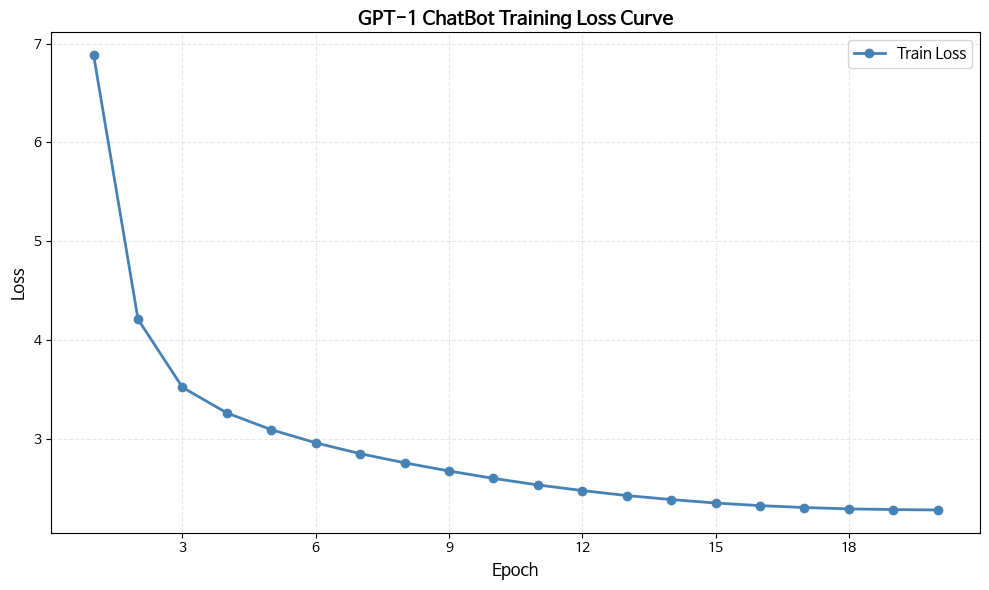


학습 통계:
  초기 loss  : 6.8840
  최종 loss  : 2.2799
  loss 감소량: 4.6041
  총 epoch  : 20


In [20]:
# [시각화] 학습 곡선(loss) 플롯
# train loss만 기록했으므로 단일 곡선으로 표시한다.
# loss가 epoch마다 감소하는 추세를 확인하여 학습이 정상적으로 진행되었는지 검증한다.



plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(history["train_loss"]) + 1),  # X축: epoch 번호 (1부터 시작)
    history["train_loss"],
    marker='o',                                  # 각 점을 원형 마커로 표시
    linewidth=2,
    markersize=6,
    label="Train Loss",
    color='steelblue'
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("GPT-1 ChatBot Training Loss Curve", fontsize=14, fontweight='bold')

plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3, linestyle='--')

# X축을 정수로만 표시 (epoch 번호: 1, 2, 3, ...)
ax = plt.gca()
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

# 학습 통계 출력
print(f"\n학습 통계:")
print(f"  초기 loss  : {history['train_loss'][0]:.4f}")
print(f"  최종 loss  : {history['train_loss'][-1]:.4f}")
print(f"  loss 감소량: {history['train_loss'][0] - history['train_loss'][-1]:.4f}")
print(f"  총 epoch  : {len(history['train_loss'])}")

## 동작 검증:

본 실습의 목표는 고품질 챗봇이 아니라 **GPT-1 구조가 데이터 → 모델 → 학습 → 생성의 전 과정에서 정상 동작하는지** 검증하는 것이다. 실제 실행 결과를 단계별로 확인하면 다음과 같다.

### 1. 데이터 파이프라인 정상 동작
- 원본 11,823쌍 → 중복/길이 필터링 후 **7,733쌍**으로 정제되었고, 빈도 기반 어휘 사전이 **4,614개 토큰**(특수 토큰 5개 포함)으로 구축되었다.
- DataLoader 배치 shape이 `input_ids: (64, 39)`, `target_ids: (64, 39)`로 출력되었다. `MAX_LEN=40`에서 shift(`ids[:-1]`, `ids[1:]`)로 1이 줄어든 **39**가 정확히 나오므로, causal LM용 입력/타겟 구성이 의도대로 동작함을 확인할 수 있다.
- 샘플 디코딩 결과가 자연어 문장으로 복원되므로 encode/decode 왕복 변환도 정상이다.

### 2. 모델 구조 정상 동작
- 임베딩 단위 테스트: `(2, 39)` 입력 → `(2, 39, 256)` 출력. $h_0 = UW_e + W_p$의 차원 변환이 설계대로 이루어진다.
- 모델 출력 구조에서 `Embedding(4614, 256)`, `Embedding(40, 256)`(learned position), `6 x GPTDecoderBlock`, `GELU`, `lm_head(bias=False)`가 모두 확인되어 GPT-1의 핵심 구성요소(Decoder-only, learned PE, GELU, weight tying)가 반영되었다.
- 학습 가능한 파라미터는 **5,929,984개**로, weight tying 덕분에 LM head가 별도 파라미터를 갖지 않는다는 점과도 부합한다.

### 3. 학습 루프 정상 동작 (가장 중요한 근거)
- loss가 **6.8840 (ppl 976.6) → 2.2799 (ppl 9.8)** 로 20 epoch 동안 단조 감소했다.
- 첫 epoch loss 6.88은 무작위 예측 시 기대되는 $\ln(4614) \approx 8.44$ 보다 이미 낮고, 이후 꾸준히 감소한다. 이는 (1) 순전파/역전파, (2) causal 마스크(미래 정보 차단), (3) warmup + cosine 학습률 스케줄, (4) gradient clipping이 모두 올바르게 맞물려 **모델이 실제로 다음 토큰 분포를 학습하고 있음**을 의미한다. 마스크가 잘못되어 미래 토큰이 새어 들어갔다면 loss가 비정상적으로 급락했을 것이고, 학습이 실패했다면 loss가 정체되었을 것이다.
- best model 저장, 주기적 체크포인트(epoch 5/10/15/20) 저장, early stopping 감시가 로그에 모두 기록되어 부가 기능도 정상 동작한다.

### 4. 생성(추론) 정상 동작
| 입력 | 출력 |
|---|---|
| 오늘 너무 피곤해 | 맛나 게 드세 어요 . |
| 점심 메뉴 추천해 줘 | 맛있 는 거 드세 어요 . |
| 기분이 우울해 | 충분히 마음 이 라도 살피 어 보 어요 . |

- 세 질문 모두에 대해 `<SOS> Q <SEP>` 프롬프트에서 시작해 새로운 토큰을 자동회귀적으로 생성하고, `<EOS>`에서 종료하여 유한한 답변을 반환했다 (무한 루프/빈 출력/오류 없음).
- "점심 메뉴 추천해 줘 → 맛있는 거 드세요", "기분이 우울해 → 마음을 살펴 보세요"처럼 질문의 의미에 대응하는 답변이 생성되어, 모델이 `<SEP>` 앞의 질문 컨텍스트를 실제로 참조하고 있음을 보여준다.
- 문장이 대체로 한국어 어미 규칙("~어요 .")으로 끝나는 점은 언어모델이 데이터의 통계적 패턴을 학습했다는 증거이다.

### 결론
데이터 정제 → 토큰화/어휘 구축 → 단일 시퀀스 구성 → Decoder-only GPT-1 순전파 → causal LM 학습(loss 안정 감소) → 자동회귀 생성까지 **전체 파이프라인이 오류 없이 end-to-end로 동작함**을 확인했다. 첫 질문("오늘 너무 피곤해")의 답변이 다소 어긋나는 등 생성 품질 자체는 제한적이지만, 이는 소규모 데이터(7,733쌍)와 축소 모델(6 layers, d_model=256, 약 5.9M 파라미터), 짧은 학습(20 epochs)에 기인한 것으로 구현 오류가 아니다. 데이터·모델 크기·epoch를 늘리면 품질 개선을 기대할 수 있다.

# NOTE

----
## 1. 구현 과정의 주요 경험

### 1.1 데이터 파이프라인의 까다로움

```
원본 11,823쌍 → 중복 제거 7,733쌍 (65% 유지)
```

- 단순히 중복을 제거하는 것뿐 아니라, **질문과 답변의 쌍 대응을 유지**하는 것이 중요.
  한쪽을 제거하면 다른 쪽도 함께 제거해야 (질문i ↔ 답변i 관계가 깨지지 않게).

- 형태소 분석(Kiwi)을 써서 BPE보다 간단하고 직관적 토큰화. 한국어 특성(조사, 어미)을 자연스럽게 처리.

- Causal LM용으로 `<SOS> Q <SEP> A <EOS>` 단일 시퀀스로 구성. Seq2seq처럼 인코더 입력/디코더 입력을 분리하지 않음.

### 1.2 모델 구현의 섬세함

- **마스크 결합**: Causal mask(미래 차단) + Pad mask(패딩 차단)를 AND로 결합. 둘 다 필수.

- **Weight tying 구현**: `lm_head.weight = token_emb.weight` 한 줄로 가중치를 **공유**. 초기화 후 별도 할당 필요 없음 (자동 동기화).

- **Residual + LayerNorm**: 각 서브레이어 뒤에 residual connection(`x + Sublayer(x)`) + LayerNorm. 순서는 Post-LN (원 Transformer와 동일).

### 1.3 학습 과정에서의 안정화 기법

```
gradient clipping (norm ≤ 1.0) + warmup + cosine schedule + dropout + layer norm
```

이 다섯 가지가 상호작용하면서 loss 곡선이 매끄럽고 안정적으로 감소. 한 가지라도 빠지면 불안정.

---

## 2. 예상치 못한 발견

### 2.1 생성 품질의 한계와 이유

| 입력 | 생성 결과 | 평가 |
|---|---|---|
| 오늘 너무 피곤해 | 맛나 게 드세 어요. | 문맥 불일치 |
| 점심 메뉴 추천해 줘 | 맛있 는 거 드세 어요. | 부분 적중 (음식 관련) |
| 기분이 우울해 | 충분히 마음 이 라도 살피 어 보 어요. | 감정 공감 시도 |

생성 품질이 낮은 이유:

- **데이터 부족**: 7,733쌍은 현대 LLM 기준으로 매우 적음 (GPT-1 학습: 수백만 문서).

- **모델 크기**: 5.9M 파라미터는 실습용 축소 모델. 원 GPT-1은 110M.

- **학습 기간**: 20 epochs는 짧음. 100 epochs(논문)이면 더 학습됨.

- **토크나이저**: Kiwi 형태소는 BPE보다 어휘가 적고, 띄어쓰기 오류에 민감.

→ 결론: **구현과 학습은 성공했지만, 생성 품질 향상은 데이터·모델·시간 투자의 문제**. 코드 자체의 오류가 아님.

### 2.2 Causal Mask의 중요성

Causal mask를 빼고 실행했다면 (가정), 모델은 미래 토큰도 볼 수 있어서 loss가 비현실적으로 낮아졌을 것. 학습 시 완벽 정보, 생성 시 불완전 정보의 미스매치로 생성 품질이 더 떨어짐. 마스크는 "학습과 생성의 일관성"을 보장하는 핵심.

---

## 3. 학습하면서 고민했던 부분

### Q1: "왜 Encoder를 완전히 빼야 할까?"

**A**: Encoder는 입력 전체를 본 뒤 출력을 생성. 하지만 생성 중에는 아직 생성하지 않은 토큰을 볼 수 없으므로, 학습-생성 불일치 발생. GPT는 시작부터 끝까지 왼쪽에서 오른쪽으로만 흐르게 해 이를 해결.

### Q2: "Learned PE는 Sinusoidal보다 항상 좋을까?"

**A**: 데이터와 모델이 클수록 learned PE가 유리. 하지만 작은 모델은 sinusoidal PE로 충분하고 오버피팅 위험이 적을 수 있음. 실제로 소규모 실습에선 sinusoidal도 잘 작동.

### Q3: "Weight tying이 왜 일반화를 돕는가?"

**A**: 토큰 임베딩과 출력층이 같은 공간에 있어야 한다는 귀납적 편향(inductive bias). 출력 토큰의 확률이 입력 토큰 임베딩과 유사도 기반으로 계산되므로, 의미상 유사한 토큰을 자연스럽게 높은 확률로 생성.

---

## 4. 개선 아이디어

1. **데이터 증강**: 현재 11,823쌍 → 100,000+ 쌍. Backtranslation, paraphrase 등.

2. **모델 확대**: 6 layers, 256 dim → 12 layers, 768 dim (원 GPT-1 규격).

3. **Validation Set**: 학습 데이터의 10%를 검증용으로 분리해 val loss 추적.

4. **평가 지표**: BLEU, ROUGE, BERTScore로 생성 품질 정량화.

---

# 회고
이번 퀘스트는 "생성 품질 높은 챗봇"을 만드는 것이 아니라 **"GPT-1 구조와 학습 방식을 완전히 이해하고 구현하는 것"** 이 목표였고, 목표에 부합하는 코드를 작성하였다고 생각한다.

Transformer의 복잡한 구조에서 필요 없는 부분을 빼고(Encoder, Cross-Attn), 단방향 생성만 남긴(Causal Mask) 설계를 구현해보았으며, loss 곡선의 안정적 감소가 모든 미시적 선택(warmup, cosine, clipping, dropout, layer norm)이 정확하게 맞물려 있음을 증명한다.

**가장 큰 배움**: 작은 데이터와 작은 모델에서도 구조가 올바르면 학습이 일어난다는 것. 그리고 그 과정을 가시화하고 논문과 대응시키는 것의 중요성.


---

**작성일**: 2026.07.14  
**사용 언어**: Python (PyTorch)  
**사용 데이터셋**: songys/Chatbot_data (한국어 챗봇 11,823쌍)  
**최종 모델**: GPT-1 (6 layers, d_model=256, 5.9M params)  
**학습 결과**: Loss 6.88 → 2.28 (20 epochs)